<a href="https://colab.research.google.com/github/oaseilmu/startbootstrap-sb-admin/blob/master/Clustering_Quran_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📖 Clustering Terjemahan Al-Qur'an — Pipeline Lengkap
**Penelitian:** Analisis Komparatif K-Means, AHC & DBSCAN pada Terjemahan Ayat Al-Qur'an Terkait E-Commerce

**Dataset:** `quran_ecommerce_clustering.xlsx` — Sheet: `Semua Ayat` — 265 ayat hasil kurasi tematik

**Konsistensi Metode:** Pipeline ini mengikuti struktur yang sama dengan notebook Fatwa DSN-MUI
agar hasil clustering kedua dataset dapat dibandingkan secara konseptual (Selaras / Parsial / GAP).

---
| Cell | Tahap |
|------|-------|
| 1 | Instalasi Library |
| 2 | Load & Eksplorasi Dataset |
| 3 | Preprocessing Teks |
| 4 | TF-IDF Vectorization |
| 5 | TruncatedSVD — Reduksi Dimensi |
| 6 | Parameter Selection — K-Means (Elbow + Silhouette) |
| 7 | Parameter Selection — DBSCAN (k-distance Plot) |
| 8 | Parameter Selection — AHC (Dendrogram) |
| 9 | Clustering — K-Means |
| 10 | Clustering — DBSCAN |
| 11 | Clustering — AHC |
| 12 | Evaluasi & Perbandingan Algoritma (Fair Comparison) |
| 13 | Pilih Algoritma Terbaik |
| 14 | Interpretasi Cluster & Top Terms |
| 15 | Mapping ke Siklus E-Commerce |
| 16 | Export Hasil |

# New Section

## 📦 Cell 1 — Instalasi Library

In [1]:
!pip install PySastrawi openpyxl seaborn -q

import Sastrawi
print('✅ Semua library siap')

✅ Semua library siap


## 📂 Cell 2 — Load & Eksplorasi Dataset

> Upload file `quran_ecommerce_clustering.xlsx` ke Colab, atau sesuaikan `FILE_PATH`.

In [5]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
    print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')


Saving quran_ecommerce_clustering.xlsx to quran_ecommerce_clustering.xlsx
User uploaded file "quran_ecommerce_clustering.xlsx" with length 78400 bytes


Total ayat   : 265
Kolom        : ['Cluster', 'Rule ID', 'Surah', 'Nama Surah', 'Ayat', 'Terjemahan ID']

Distribusi CLUSTER (Ground Truth dari kurasi manual):
Cluster
3. Listing & Marketing         131
5. Fulfillment-Delivery         59
2. Warehouse-Inventory          42
6b. AfterSales-Restitution      12
6a. AfterSales-Dispute          12
4a. Transactions-Riba            6
1. Procurement-Dropshipping      1
4b. Transactions-Debt&Doc        1
4c. Transactions-Consent         1
Name: count, dtype: int64

Statistik panjang teks (kata):
count    265.0
mean      35.9
std       24.8
min        4.0
25%       19.0
50%       31.0
75%       44.0
max      218.0
Name: Jml_Kata, dtype: float64


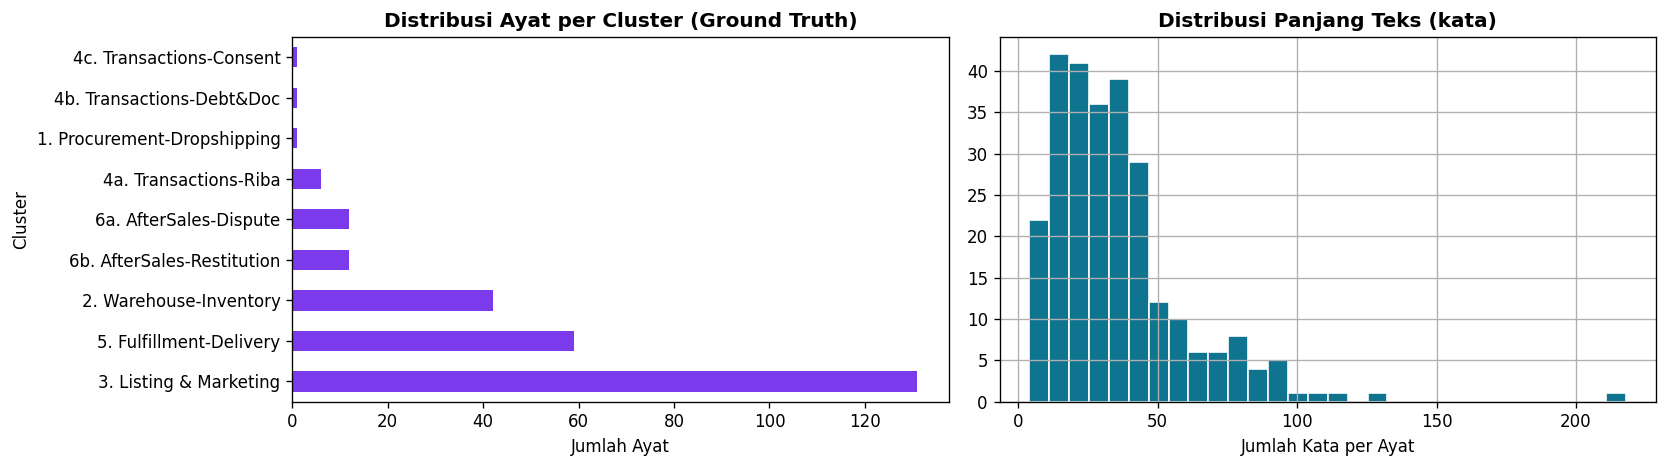

,Cluster,Rule ID,Surah,Nama Surah,Ayat,Terjemahan ID,Jml_Kata
0,1. Procurement-Dropshipping,procurement_strict,4,An-Nisa',29,"Wahai orang-orang yang beriman, janganlah kamu...",36
1,2. Warehouse-Inventory,inventory,2,Al-Baqarah,279,"Jika kamu tidak melaksanakannya, ketahuilah ak...",32
2,2. Warehouse-Inventory,inventory,3,Ali ‘Imran,176,Janganlah engkau (Nabi Muhammad) dirisaukan ol...,37


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

# ── Sesuaikan path file ──────────────────────────────────────────
FILE_PATH = 'quran_ecommerce_clustering.xlsx'
# FILE_PATH = '/content/drive/MyDrive/TA/quran_ecommerce_clustering.xlsx'
# ─────────────────────────────────────────────────────────────────

df = pd.read_excel(FILE_PATH, sheet_name='Semua Ayat')

print(f'Total ayat   : {len(df):,}')
print(f'Kolom        : {df.columns.tolist()}')
print(f'\nDistribusi CLUSTER (Ground Truth dari kurasi manual):')
print(df['Cluster'].value_counts())
print(f'\nStatistik panjang teks (kata):')
df['Jml_Kata'] = df['Terjemahan ID'].str.split().str.len()
print(df['Jml_Kata'].describe().round(1))

# Visualisasi distribusi
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['Cluster'].value_counts().plot(kind='barh', ax=axes[0], color='#7C3AED')
axes[0].set_title('Distribusi Ayat per Cluster (Ground Truth)', fontweight='bold')
axes[0].set_xlabel('Jumlah Ayat')
df['Jml_Kata'].hist(bins=30, ax=axes[1], color='#0E7490', edgecolor='white')
axes[1].set_title('Distribusi Panjang Teks (kata)', fontweight='bold')
axes[1].set_xlabel('Jumlah Kata per Ayat')
plt.tight_layout(); plt.show()

df.head(3)

## 🧹 Cell 3 — Preprocessing Teks

Pipeline: **Case Folding → Tokenisasi → Stopword Removal → Stemming**

> **Catatan khusus Quran:** Terjemahan mengandung banyak kata sifat Tuhan (Maha Mengetahui,
> Maha Bijaksana, dst.) yang tidak relevan untuk clustering tematik muamalah.
> Kata-kata ini ditambahkan ke custom stopword agar tidak mendominasi TF-IDF.
> Sebaliknya, istilah muamalah kunci dilindungi dari stemming via whitelist.

In [ ]:
import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

stemmer  = StemmerFactory().create_stemmer()
sw_base  = set(StopWordRemoverFactory().get_stop_words())

# ── Stopword custom untuk terjemahan Quran ────────────────────────
# Kata-kata umum dalam terjemahan yang tidak informatif untuk clustering muamalah
CUSTOM_SW = {
    # Kata sapaan & pronomen khas terjemahan
    'wahai','sesungguhnya','sungguh','katakanlah','katakan','nabi','muhammad',
    'allah','tuhan','rasul','dia','mereka','kamu','kami','kita','engkau',
    'dirimu','dirinya','kalian','orang',
    # Sifat Allah yang sering muncul tapi tidak relevan
    'maha','mengetahui','bijaksana','penyayang','pengampun','pemaaf','pengasih',
    'kuasa','berkuasa','mendengar','melihat','besar','agung','tinggi','mulia',
    # Kata umum terjemahan
    'sesungguhnya','bahwasanya','tidaklah','tidaknya','janganlah','oleh',
    'kepada','dengan','dalam','untuk','dari','pada','akan','telah','sudah',
    'adalah','itu','ini','yang','dan','atau','jika','maka','sehingga',
    'ketika','setelah','sebelum','karena','sebab','agar','supaya','bahwa',
    'adapun','apabila','setiap','semua','segala','selain','kecuali',
    'yaitu','yakni','juga','pun','lagi','hanya','saja','begitu','demikian',
    'suatu','sesuatu','hal','hari','tahun','waktu','saat',
    # Kata akhirat/eskatologi (tidak relevan untuk e-commerce)
    'akhirat','surga','neraka','azab','siksa','pahala','dosa','tobat',
    'kiamat','akhir','kekal','abadi','syurga','jahannam',
    # Kata perang/konflik (konteks berbeda dengan muamalah)
    'perang','berperang','membunuh','bunuh','kekufuran','kafir','munafik',
}

# ── Whitelist — istilah muamalah yang TIDAK boleh di-stem ─────────
WHITELIST = {
    # Akad & transaksi
    'jual','beli','dagang','niaga','perniagaan','transaksi','akad',
    'utang','piutang','hutang','pinjam','kredit','cicil',
    'riba','bunga','gharar','penipuan','curang','batil',
    'harga','bayar','modal','untung','rugi','laba',
    # Amanah & kejujuran
    'amanah','jujur','adil','zalim','aniaya','curang','khianat',
    'saksi','kesaksian','sumpah','janji','kontrak',
    # Hak & kewajiban
    'hak','kewajiban','harta','milik','kepemilikan',
    'zakat','sedekah','infak','wakaf',
    # Logistik & penyimpanan
    'simpan','titip','amanah','jaga','pelihara','stok','gudang',
    # Sengketa & penyelesaian
    'sengketa','hakim','pengadilan','keputusan','ganti','rugi','kompensasi',
    'retur','kembali','pengembalian',
    # Dokumen & pencatatan
    'catat','tulis','dokumen','catatan','rekam','bukti',
}

ALL_SW = (sw_base | CUSTOM_SW) - WHITELIST

def preprocess(text):
    text = str(text).lower()
    # Hapus tanda kurung beserta isinya (sering berisi keterangan penerjemah)
    text = re.sub(r'\(.*?\)', ' ', text)
    text = re.sub(r'https?\S+', ' ', text)
    text = re.sub(r"[^a-z\s']", ' ', text)
    text = re.sub(r"'", '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = re.findall(r'[a-z]+', text)
    tokens = [t for t in tokens if t not in ALL_SW or t in WHITELIST]
    tokens = [t if t in WHITELIST else stemmer.stem(t) for t in tokens]
    tokens = [t for t in tokens if len(t) > 2]
    return ' '.join(tokens)

print('Memproses teks...')
df['text_processed'] = df['Terjemahan ID'].apply(preprocess)
print('✅ Preprocessing selesai')

# Cek hasil
print('\nContoh hasil preprocessing:')
for i in [0, 50, 100]:
    print(f'\n[Ayat {i}] ASLI    : {df["Terjemahan ID"].iloc[i][:100]}')
    print(f'[Ayat {i}] PROCESSED: {df["text_processed"].iloc[i][:100]}')

# Cek ayat yang terlalu pendek setelah preprocessing
df['n_token'] = df['text_processed'].str.split().str.len()
pendek = df[df['n_token'] < 3]
print(f'\nAyat dengan token < 3 setelah preprocessing: {len(pendek)}')
if len(pendek) > 0:
    print(pendek[['Surah','Ayat','Terjemahan ID','text_processed']].to_string())

## 🔢 Cell 4 — TF-IDF Vectorization

> **Catatan:** Dataset ayat lebih kecil (265 dok) dibanding fatwa (~1.258 dok),
> sehingga `max_features` dan `min_df` disesuaikan agar tidak over-filter.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

corpus = df['text_processed'].tolist()

vectorizer = TfidfVectorizer(
    ngram_range  = (1, 2),   # unigram + bigram
    max_features = 2000,     # lebih kecil dari fatwa karena corpus lebih kecil
    min_df       = 2,        # abaikan term yang hanya muncul 1x
    max_df       = 0.90,
    sublinear_tf = True,
    norm         = 'l2',
)

X_tfidf = vectorizer.fit_transform(corpus)
vocab   = vectorizer.get_feature_names_out()
sparsity = 1 - (X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]))

print(f'Jumlah dokumen (ayat) : {X_tfidf.shape[0]}')
print(f'Ukuran kosakata       : {X_tfidf.shape[1]:,} fitur')
print(f'Sparsity              : {sparsity:.2%}')

mean_tfidf = np.array(X_tfidf.mean(axis=0)).flatten()
top20 = mean_tfidf.argsort()[::-1][:20]
print('\nTop 20 term (rata-rata bobot TF-IDF):')
for rank, idx in enumerate(top20, 1):
    print(f'  {rank:2d}. {vocab[idx]:<35s} {mean_tfidf[idx]:.4f}')

## 📐 Cell 5 — TruncatedSVD / LSA (Reduksi Dimensi)

Karena dataset lebih kecil (265 dok), jumlah komponen SVD disesuaikan menjadi **50**
agar tidak melebihi jumlah dokumen dan menghindari overfitting pada dimensi reduksi.

In [ ]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline

# Dataset 265 dok → 50 komponen cukup (aturan: N_COMPONENTS << N_docs)
N_COMPONENTS = 50

svd        = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
normalizer = Normalizer(copy=False)
lsa_pipe   = make_pipeline(svd, normalizer)

X_lsa = lsa_pipe.fit_transform(X_tfidf)

exp_var = svd.explained_variance_ratio_.sum()
print(f'Dimensi setelah SVD  : {X_lsa.shape}')
print(f'Explained variance   : {exp_var:.2%}')

plt.figure(figsize=(9, 3))
plt.plot(np.cumsum(svd.explained_variance_ratio_), color='#7C3AED', linewidth=2)
plt.axhline(0.8, color='gray', linestyle='--', alpha=0.6, label='80% threshold')
plt.axvline(N_COMPONENTS, color='#DC2626', linestyle=':', alpha=0.7,
            label=f'n={N_COMPONENTS} komponen')
plt.xlabel('Jumlah Komponen SVD')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance TruncatedSVD — Terjemahan Al-Qur\'an')
plt.legend()
plt.tight_layout(); plt.show()

tfidf_dense = X_tfidf.toarray()
print('\nX_lsa siap untuk clustering.')

## 🔍 Cell 6 — Parameter Selection: K-Means (Elbow + Silhouette + DBI)

Uji K = 2 sampai 12.

> **Catatan:** Dataset Quran memiliki 9 sub-cluster ground truth yang dikelompokkan menjadi
> 6 siklus. Maka range K yang relevan adalah **4–9**. Kita tetap scan 2–12 untuk kelengkapan.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

K_RANGE = range(2, 13)
inertia_list = []
sil_list_km  = []
dbi_list_km  = []

print(f"{'K':>3}  {'Inertia':>12}  {'Silhouette':>12}  {'DBI':>8}")
print('-' * 42)

for k in K_RANGE:
    km  = KMeans(n_clusters=k, init='k-means++', n_init=10,
                 max_iter=300, random_state=42)
    lbl = km.fit_predict(X_lsa)
    inertia_list.append(km.inertia_)
    sil = silhouette_score(X_lsa, lbl, metric='cosine')
    dbi = davies_bouldin_score(X_lsa, lbl)
    sil_list_km.append(sil)
    dbi_list_km.append(dbi)
    print(f"{k:>3}  {km.inertia_:>12.2f}  {sil:>12.4f}  {dbi:>8.4f}")

ks = list(K_RANGE)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(ks, inertia_list, 'o-', color='#7C3AED', lw=2)
axes[0].set(xlabel='K', ylabel='Inertia (SSE)', title='Elbow Method')
axes[0].set_xticks(ks); axes[0].grid(alpha=0.3)

best_sil_k = ks[np.argmax(sil_list_km)]
axes[1].plot(ks, sil_list_km, 'o-', color='#0E7490', lw=2)
axes[1].axvline(best_sil_k, color='red', ls='--', alpha=0.7, label=f'Best K={best_sil_k}')
axes[1].set(xlabel='K', ylabel='Silhouette', title='Silhouette Score per K')
axes[1].legend(); axes[1].set_xticks(ks); axes[1].grid(alpha=0.3)

best_dbi_k = ks[np.argmin(dbi_list_km)]
axes[2].plot(ks, dbi_list_km, 'o-', color='#B45309', lw=2)
axes[2].axvline(best_dbi_k, color='red', ls='--', alpha=0.7, label=f'Best K={best_dbi_k}')
axes[2].set(xlabel='K', ylabel='DBI (lebih rendah = baik)', title='Davies-Bouldin Index per K')
axes[2].legend(); axes[2].set_xticks(ks); axes[2].grid(alpha=0.3)

plt.suptitle('Parameter Selection — K-Means (Translation of Al-Qur\'an)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'\nRekomendasi K (Silhouette) : K = {best_sil_k}')
print(f'Rekomendasi K (DBI)        : K = {best_dbi_k}')
print(f'Ground truth sub-cluster   : 9 (dikelompokkan jadi 6 siklus)')

K_OPTIMAL_KMEANS = best_sil_k
# K_OPTIMAL_KMEANS = 6   # override manual jika ingin sesuaikan dengan 6 siklus

## 🔍 Cell 7 — Parameter Selection: DBSCAN (k-distance Plot + Grid Search)

**Catatan fair comparison:** Silhouette DBSCAN dihitung dengan penalti noise (skor = -1 untuk
noise points) agar perbandingan dengan K-Means dan AHC tidak bias.

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

def silhouette_noise_penalized(X, labels, metric='cosine'):
    """Silhouette score dengan noise points (label=-1) mendapat penalti skor -1.
    Membuat perbandingan fair vs K-Means/AHC yang tidak membuang data."""
    n_total = len(labels)
    mask    = labels != -1
    n_noise = n_total - mask.sum()
    if mask.sum() < 2:
        return -1.0
    n_clusters = len(set(labels[mask]))
    if n_clusters < 2:
        return -1.0
    sil_non_noise = silhouette_score(X[mask], labels[mask], metric=metric)
    return (sil_non_noise * mask.sum() + (-1.0) * n_noise) / n_total

MIN_SAMPLES_OPTIONS = [3, 5, 10]

fig, axes = plt.subplots(1, len(MIN_SAMPLES_OPTIONS), figsize=(15, 4))
knee_eps = {}

for ax, ms in zip(axes, MIN_SAMPLES_OPTIONS):
    nbrs = NearestNeighbors(n_neighbors=ms, metric='cosine').fit(X_lsa)
    dists, _ = nbrs.kneighbors(X_lsa)
    k_dists  = np.sort(dists[:, -1])[::-1]

    diff2    = np.gradient(np.gradient(k_dists))
    lo, hi   = int(len(diff2) * 0.05), int(len(diff2) * 0.5)
    knee_idx = np.argmax(np.abs(diff2[lo:hi])) + lo
    knee_val = round(k_dists[knee_idx], 3)
    knee_eps[ms] = knee_val

    ax.plot(range(len(k_dists)), k_dists, color='#7C3AED', lw=1.5)
    ax.axhline(knee_val, color='red', ls='--', alpha=0.8, label=f'eps ~ {knee_val}')
    ax.set(title=f'k-distance (min_samples={ms})',
           xlabel='Titik (diurutkan)', ylabel=f'Jarak ke-{ms}NN')
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Parameter Selection — DBSCAN (Terjemahan Al-Qur\'an)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print('\nEstimasi epsilon per min_samples:')
for ms, eps in knee_eps.items():
    print(f'  min_samples={ms:2d}  ->  eps ~ {eps}')

print(f"\n{'eps':>8}  {'min_s':>6}  {'n_clust':>8}  {'noise%':>7}  {'sil_penalized':>15}  {'sil_filtered':>14}  {'dbi':>8}")
print('-' * 82)
dbscan_results = []

for ms, base_eps in knee_eps.items():
    for mult in [0.7, 0.85, 1.0, 1.2, 1.5]:
        eps = round(base_eps * mult, 3)
        db  = DBSCAN(eps=eps, min_samples=ms, metric='cosine')
        lbl = db.fit_predict(X_lsa)
        n_cl     = len(set(lbl)) - (1 if -1 in lbl else 0)
        n_noise  = int(np.sum(lbl == -1))
        noisepct = n_noise / len(lbl) * 100
        if n_cl >= 2:
            mask = lbl != -1
            sil_pen = silhouette_noise_penalized(X_lsa, lbl, metric='cosine')
            sil_flt = silhouette_score(X_lsa[mask], lbl[mask], metric='cosine') if mask.sum() > n_cl else -1
            dbi     = davies_bouldin_score(X_lsa[mask], lbl[mask]) if mask.sum() > n_cl else 99
        else:
            sil_pen, sil_flt, dbi = -1, -1, 99
        dbscan_results.append(dict(eps=eps, min_samples=ms, n_clusters=n_cl,
                                   noise_pct=noisepct, sil_penalized=sil_pen,
                                   sil_filtered=sil_flt, dbi=dbi))
        print(f"{eps:>8.3f}  {ms:>6}  {n_cl:>8}  {noisepct:>6.1f}%  "
              f"{sil_pen:>15.4f}  {sil_flt:>14.4f}  {dbi:>8.4f}")

df_db_res = pd.DataFrame(dbscan_results)
valid = df_db_res[(df_db_res.n_clusters >= 2) & (df_db_res.noise_pct < 30)]

if len(valid) > 0:
    best_db = valid.loc[valid.sil_penalized.idxmax()]
    EPS_OPTIMAL    = best_db['eps']
    MINPTS_OPTIMAL = int(best_db['min_samples'])
    print(f'\nParameter terbaik (noise-penalized): eps={EPS_OPTIMAL}, min_samples={MINPTS_OPTIMAL}')
    print(f'  -> {int(best_db.n_clusters)} cluster, noise {best_db.noise_pct:.1f}%')
    print(f'     Sil penalized={best_db.sil_penalized:.4f} | Sil filtered={best_db.sil_filtered:.4f}')
else:
    print('\nTidak ada kombinasi valid, pakai fallback.')
    EPS_OPTIMAL, MINPTS_OPTIMAL = 0.3, 5

# EPS_OPTIMAL    = 0.25
# MINPTS_OPTIMAL = 5
print(f'\nEPS_OPTIMAL={EPS_OPTIMAL}, MINPTS_OPTIMAL={MINPTS_OPTIMAL}')

## 🔍 Cell 8 — Parameter Selection: AHC (Dendrogram + Scan K)

> **Konsistensi:** Ward linkage dikecualikan — semua AHC menggunakan metric='cosine'
> agar fitting dan evaluasi menggunakan metric yang sama.

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

# Dendrogram — semua 265 dok bisa divisualisasikan (tidak terlalu besar)
N_SAMPLE = min(265, len(X_lsa))
np.random.seed(42)
idx_s  = np.random.choice(len(X_lsa), N_SAMPLE, replace=False)
X_s    = X_lsa[idx_s]
dist_m = pdist(X_s, metric='cosine')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, method in zip(axes, ['average', 'complete']):
    Z = linkage(dist_m, method=method)
    dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
               leaf_rotation=90, leaf_font_size=7,
               show_contracted=True,
               color_threshold=0.7 * max(Z[:, 2]))
    ax.set(title=f'Dendrogram — {method.capitalize()} Linkage\n({N_SAMPLE} dok.)',
           xlabel='Dokumen', ylabel='Jarak (cosine)')
plt.suptitle('Dendrogram AHC — Terjemahan Al-Qur\'an', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Scan K — hanya average & complete (cosine konsisten)
LINKAGE_OPTIONS = ['average', 'complete']

print(f"{'K':>4}  {'Linkage':>10}  {'Silhouette (cosine)':>20}  {'DBI':>8}")
print('-' * 48)
ahc_results = []

for link in LINKAGE_OPTIONS:
    for k in range(2, 13):
        ahc = AgglomerativeClustering(n_clusters=k, linkage=link, metric='cosine')
        lbl = ahc.fit_predict(X_lsa)
        sil = silhouette_score(X_lsa, lbl, metric='cosine')
        dbi = davies_bouldin_score(X_lsa, lbl)
        ahc_results.append(dict(k=k, linkage=link, silhouette=sil, dbi=dbi))
        print(f"{k:>4}  {link:>10}  {sil:>20.4f}  {dbi:>8.4f}")

df_ahc_res  = pd.DataFrame(ahc_results)
best_ahc    = df_ahc_res.loc[df_ahc_res.silhouette.idxmax()]
K_OPTIMAL_AHC       = int(best_ahc['k'])
LINKAGE_OPTIMAL_AHC = best_ahc['linkage']

print(f'\nAHC terbaik: K={K_OPTIMAL_AHC}, linkage="{LINKAGE_OPTIMAL_AHC}"')
print(f'  Silhouette={best_ahc.silhouette:.4f}, DBI={best_ahc.dbi:.4f}')

# K_OPTIMAL_AHC       = 6
# LINKAGE_OPTIMAL_AHC = 'average'

## 🤖 Cell 9 — Clustering: K-Means

In [ ]:
km_final  = KMeans(n_clusters=K_OPTIMAL_KMEANS, init='k-means++',
                   n_init=20, max_iter=500, random_state=42)
km_labels = km_final.fit_predict(X_lsa)
df['cluster_kmeans'] = km_labels

km_sil = silhouette_score(X_lsa, km_labels, metric='cosine')
km_dbi = davies_bouldin_score(X_lsa, km_labels)

print(f'=== K-Means (K={K_OPTIMAL_KMEANS}) ===')
print(f'Silhouette : {km_sil:.4f}')
print(f'DBI        : {km_dbi:.4f}')
print('\nDistribusi cluster:')
for c, cnt in pd.Series(km_labels).value_counts().sort_index().items():
    print(f'  C{c:2d}: {cnt:4d} ayat  {chr(9608) * (cnt // 3)}')

km_top_terms = {}
print('\nTop 10 terms per cluster:')
for c in range(K_OPTIMAL_KMEANS):
    mask     = km_labels == c
    mean_vec = tfidf_dense[mask].mean(axis=0)
    top_idx  = mean_vec.argsort()[::-1][:10]
    terms    = [(vocab[i], round(float(mean_vec[i]), 4)) for i in top_idx]
    km_top_terms[c] = terms
    print(f'  C{c:2d}: {", ".join(t[0] for t in terms)}')

## 📊 Silhouette Plot — K-Means (K Optimal)

> **Cara baca:**
> - Setiap **blok warna** = satu cluster
> - Setiap **bar horizontal** = satu dokumen; panjang bar = nilai silhouette-nya
> - **Garis merah putus-putus** = rata-rata silhouette keseluruhan
> - Cluster yang baik: bar seragam panjang & tidak ada yang negatif
> - Cluster yang buruk: banyak bar pendek/negatif = dokumen tidak cocok di cluster-nya


In [ ]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# ── Hitung silhouette per dokumen ─────────────────────────────────
sil_vals   = silhouette_samples(X_lsa, km_labels, metric='cosine')
sil_avg    = silhouette_score(X_lsa, km_labels, metric='cosine')
n_clusters = K_OPTIMAL_KMEANS
cluster_ids_sorted = sorted(set(km_labels))

# ── Layout: silhouette plot kiri + distribusi kanan ───────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, max(7, n_clusters * 0.8)))

# Palet warna — satu warna per cluster
colors = cm.tab20(np.linspace(0, 1, n_clusters))

y_lower = 10
cluster_centers_sil = []

for i, cl in enumerate(cluster_ids_sorted):
    cl_sil = np.sort(sil_vals[km_labels == cl])
    size_cl = len(cl_sil)
    y_upper = y_lower + size_cl

    ax1.fill_betweenx(
        np.arange(y_lower, y_upper),
        0, cl_sil,
        facecolor=colors[i], edgecolor=colors[i], alpha=0.85
    )
    # Label cluster di tengah blok
    center_y = (y_lower + y_upper) / 2
    cluster_centers_sil.append(center_y)
    ax1.text(-0.07, center_y, f'C{cl}', ha='center', va='center',
             fontsize=8, fontweight='bold', color=colors[i])
    y_lower = y_upper + 10  # gap antar cluster

# Garis rata-rata silhouette
ax1.axvline(x=sil_avg, color='red', linestyle='--', linewidth=1.5,
            label=f'Rata-rata = {sil_avg:.4f}')
ax1.set_xlim([-0.15, 0.6])
ax1.set_xlabel('Silhouette Coefficient', fontsize=11)
ax1.set_ylabel('Dokumen (dikelompokkan per cluster)', fontsize=11)
ax1.set_title(f'Silhouette Plot — K-Means (K={n_clusters})\nDataset Terjemahan Al-Qur\'an',
              fontsize=12, fontweight='bold')
ax1.set_yticks(cluster_centers_sil)
ax1.set_yticklabels([f'C{cl}' for cl in cluster_ids_sorted], fontsize=8)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(axis='x', alpha=0.3)

# ── Panel kanan: ukuran cluster + silhouette rata-rata per cluster ─
cl_sizes  = [int(np.sum(km_labels == cl)) for cl in cluster_ids_sorted]
cl_avgsil = [float(sil_vals[km_labels == cl].mean()) for cl in cluster_ids_sorted]

bars = ax2.barh(
    [f'C{cl}' for cl in cluster_ids_sorted],
    cl_avgsil, color=colors, edgecolor='white', height=0.6
)
ax2.axvline(x=sil_avg, color='red', linestyle='--', linewidth=1.5,
            label=f'Rata-rata global = {sil_avg:.4f}')
ax2.axvline(x=0, color='black', linewidth=0.8)

# Anotasi ukuran cluster di ujung bar
for bar, size, val in zip(bars, cl_sizes, cl_avgsil):
    x_pos = val + 0.005 if val >= 0 else val - 0.005
    ha = 'left' if val >= 0 else 'right'
    ax2.text(x_pos, bar.get_y() + bar.get_height()/2,
             f'{size} dok', va='center', ha=ha, fontsize=8)

ax2.set_xlabel('Silhouette Rata-rata per Cluster', fontsize=11)
ax2.set_title('Silhouette Rata-rata & Ukuran Cluster\n(bar merah = nilai negatif = cluster buruk)',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('silhouette_plot_quran.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Ringkasan teks ────────────────────────────────────────────────
print(f'Silhouette Score rata-rata global : {sil_avg:.4f}')
print(f'Cluster dengan silhouette TERBAIK : C{cluster_ids_sorted[np.argmax(cl_avgsil)]} '
      f'(sil={max(cl_avgsil):.4f})')
negatif = [cl for cl, s in zip(cluster_ids_sorted, cl_avgsil) if s < 0]
if negatif:
    print(f'Cluster dengan silhouette NEGATIF  : {negatif} — dokumen tidak cocok di cluster ini')
else:
    print('Tidak ada cluster dengan silhouette negatif ✅')
print(f'\n✅ Gambar disimpan: silhouette_plot_quran.png')


## 🤖 Cell 10 — Clustering: DBSCAN

In [ ]:
db_final  = DBSCAN(eps=EPS_OPTIMAL, min_samples=MINPTS_OPTIMAL, metric='cosine')
db_labels = db_final.fit_predict(X_lsa)
df['cluster_dbscan'] = db_labels

n_cl_db   = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise   = int(np.sum(db_labels == -1))
noise_pct = n_noise / len(db_labels) * 100

print(f'=== DBSCAN (eps={EPS_OPTIMAL}, min_samples={MINPTS_OPTIMAL}) ===')
print(f'Jumlah cluster   : {n_cl_db}')
print(f'Noise (label=-1) : {n_noise} ({noise_pct:.1f}%)')

if n_cl_db >= 2:
    mask_db = db_labels != -1
    db_sil_filtered = silhouette_score(X_lsa[mask_db], db_labels[mask_db], metric='cosine')
    db_sil_full     = silhouette_noise_penalized(X_lsa, db_labels, metric='cosine')
    db_dbi          = davies_bouldin_score(X_lsa[mask_db], db_labels[mask_db])
    db_sil = db_sil_full  # yang dipakai untuk perbandingan
    print(f'Silhouette (filtered, tidak fair) : {db_sil_filtered:.4f}')
    print(f'Silhouette (penalized, FAIR)      : {db_sil_full:.4f}  <- dipakai perbandingan')
    print(f'DBI                               : {db_dbi:.4f}')
else:
    db_sil, db_dbi, db_sil_filtered = -1, 99, -1
    print('Kurang dari 2 cluster — metrik tidak valid.')

print('\nDistribusi cluster:')
for c, cnt in pd.Series(db_labels).value_counts().sort_index().items():
    label = 'NOISE' if c == -1 else f'C{c:2d}'
    print(f'  {label}: {cnt:4d} ayat  {chr(9608) * (cnt // 3)}')

db_top_terms = {}
print('\nTop 10 terms per cluster DBSCAN:')
for c in sorted(set(db_labels)):
    if c == -1: continue
    mask     = db_labels == c
    mean_vec = tfidf_dense[mask].mean(axis=0)
    top_idx  = mean_vec.argsort()[::-1][:10]
    terms    = [(vocab[i], round(float(mean_vec[i]), 4)) for i in top_idx]
    db_top_terms[c] = terms
    print(f'  C{c:2d}: {", ".join(t[0] for t in terms)}')

## 🤖 Cell 11 — Clustering: AHC

In [ ]:
# metric='cosine' konsisten untuk fitting DAN evaluasi
ahc_final  = AgglomerativeClustering(n_clusters=K_OPTIMAL_AHC,
                                      linkage=LINKAGE_OPTIMAL_AHC,
                                      metric='cosine')
ahc_labels = ahc_final.fit_predict(X_lsa)
df['cluster_ahc'] = ahc_labels

ahc_sil = silhouette_score(X_lsa, ahc_labels, metric='cosine')
ahc_dbi = davies_bouldin_score(X_lsa, ahc_labels)

print(f'=== AHC (K={K_OPTIMAL_AHC}, linkage="{LINKAGE_OPTIMAL_AHC}", metric=cosine) ===')
print(f'Silhouette : {ahc_sil:.4f}')
print(f'DBI        : {ahc_dbi:.4f}')
print('\nDistribusi cluster:')
for c, cnt in pd.Series(ahc_labels).value_counts().sort_index().items():
    print(f'  C{c:2d}: {cnt:4d} ayat  {chr(9608) * (cnt // 3)}')

ahc_top_terms = {}
print('\nTop 10 terms per cluster AHC:')
for c in range(K_OPTIMAL_AHC):
    mask     = ahc_labels == c
    mean_vec = tfidf_dense[mask].mean(axis=0)
    top_idx  = mean_vec.argsort()[::-1][:10]
    terms    = [(vocab[i], round(float(mean_vec[i]), 4)) for i in top_idx]
    ahc_top_terms[c] = terms
    print(f'  C{c:2d}: {", ".join(t[0] for t in terms)}')

## 📊 Cell 12 — Evaluasi & Perbandingan Ketiga Algoritma (Fair Comparison)

Dua perbaikan untuk fairness:

| # | Masalah | Perbaikan |
|---|---|---|
| 1 | Silhouette DBSCAN tanpa noise (bias) | Noise mendapat penalti **-1** → rata-rata berbobot |
| 2 | AHC Ward metric inkonsisten | Ward dihapus; semua pakai `cosine` |

> **Catatan dataset Qur'an:** Kolom `Cluster` adalah ground truth dari kurasi manual
> (9 sub-cluster → 6 siklus). Ini digunakan sebagai **validasi eksternal** via V-Measure —
> ditampilkan informatif di tabel perbandingan, **bukan** sebagai kriteria pemilihan algoritma.

In [ ]:
from sklearn.metrics import v_measure_score

algos = ['K-Means', 'DBSCAN', 'AHC']

# ── V-Measure vs Ground Truth Cluster (informatif, bukan kriteria ranking) ─
gt_codes, gt_classes = pd.factorize(df['Cluster'])
print(f'Ground truth classes ({len(gt_classes)}): {list(gt_classes)}')

vm_km  = v_measure_score(gt_codes, km_labels)
if n_cl_db >= 2:
    mask_vm = db_labels != -1
    vm_db   = v_measure_score(gt_codes[mask_vm], db_labels[mask_vm])
else:
    vm_db = 0.0
vm_ahc = v_measure_score(gt_codes, ahc_labels)

print(f'\nV-Measure vs Ground Truth (informatif):')
print(f'  K-Means : {vm_km:.4f}')
print(f'  DBSCAN  : {vm_db:.4f}  (hanya non-noise)')
print(f'  AHC     : {vm_ahc:.4f}')

# ── Ringkasan ─────────────────────────────────────────────────────
results = {
    'K-Means': dict(n_clusters=K_OPTIMAL_KMEANS, silhouette=km_sil, dbi=km_dbi,
                    vm=vm_km, noise_pct=0.0,
                    param=f'K={K_OPTIMAL_KMEANS}, k-means++'),
    'DBSCAN' : dict(n_clusters=n_cl_db, silhouette=db_sil, dbi=db_dbi,
                    vm=vm_db, noise_pct=noise_pct,
                    param=f'eps={EPS_OPTIMAL}, minPts={MINPTS_OPTIMAL}'),
    'AHC'    : dict(n_clusters=K_OPTIMAL_AHC, silhouette=ahc_sil, dbi=ahc_dbi,
                    vm=vm_ahc, noise_pct=0.0,
                    param=f'K={K_OPTIMAL_AHC}, {LINKAGE_OPTIMAL_AHC}'),
}

print()
print('=' * 100)
print("PERBANDINGAN KINERJA ALGORITMA CLUSTERING — TERJEMAHAN AL-QUR'AN")
print('(Fair comparison: Silhouette DBSCAN = noise-penalized)')
print('=' * 100)
print(f'{"Algoritma":<12} {"N Cluster":>10} {"Silhouette":>12} {"DBI":>10} {"V-Measure":<12} {"Noise%":>8}  Parameter')
print('-' * 100)
for a in algos:
    r = results[a]
    print(f'{a:<12} {r["n_clusters"]:>10} {r["silhouette"]:>12.4f} {r["dbi"]:>10.4f} '
          f'{r["vm"]:>12.4f} {r["noise_pct"]:>7.1f}%  {r["param"]}')
print('=' * 100)
print()
print('Keterangan kolom:')
print('  Silhouette  : semakin tinggi semakin baik (range -1..1)')
print('  DBI         : semakin rendah semakin baik (≥ 0)')
print('  V-Measure   : semakin tinggi semakin baik (informatif — tidak masuk ranking)')

## 🏆 Cell 13 — Pilih Algoritma Terbaik (Multi-Kriteria)

Ranking berdasarkan **2 kriteria objektif**:
- **Silhouette** (noise-penalized) — kualitas pemisahan internal
- **DBI** — kekompakan dan separasi cluster

> **Catatan V-Measure:** V-Measure tetap ditampilkan di tabel perbandingan sebagai informasi tambahan,
> tetapi **tidak ikut menentukan** algoritma terbaik. Ini menghindari *circular reasoning*:
> label `Cluster` dibuat manual → dijadikan ground truth → dipakai memilih algoritma.
>
> **Konsistensi dengan Fatwa:** Kriteria ranking identik (Silhouette + DBI), sehingga
> perbandingan antar dataset metodologis konsisten dan dapat dipertahankan di sidang.

In [ ]:
sil_rank = pd.Series({a: results[a]['silhouette'] for a in algos}).rank(ascending=False)
dbi_rank = pd.Series({a: results[a]['dbi']        for a in algos}).rank(ascending=True)

# V-Measure TIDAK masuk ranking — hanya ditampilkan informatif di tabel atas
# Memasukkan VM ke ranking = circular (label manual → ground truth → pilih algo)
total_rank = sil_rank + dbi_rank
best_algo  = total_rank.idxmin()

print('=' * 60)
print("RANKING ALGORITMA — TERJEMAHAN AL-QUR'AN")
print('Kriteria: Silhouette (fair) + DBI')
print('(V-Measure informatif — tidak ikut voting)')
print('=' * 60)
print(f'{"Algoritma":<12} {"Rank Sil":>10} {"Rank DBI":>10} {"Total":>8}')
print('-' * 48)
for a in algos:
    marker = '  <-- TERBAIK' if a == best_algo else ''
    print(f'{a:<12} {sil_rank[a]:>10.0f} {dbi_rank[a]:>10.0f} {total_rank[a]:>8.0f}{marker}')
print('=' * 60)
print(f'\nALGORITMA TERBAIK: {best_algo}')

# ── Simpan label dan top terms ─────────────────────────────────────
_col_map = {'K-Means': 'cluster_kmeans', 'DBSCAN': 'cluster_dbscan', 'AHC': 'cluster_ahc'}
_top_map  = {'K-Means': km_top_terms,    'DBSCAN': db_top_terms,     'AHC': ahc_top_terms}

BEST_COL       = _col_map[best_algo]
BEST_LABELS    = df[BEST_COL].values
BEST_TOP_TERMS = _top_map[best_algo]
N_BEST         = len(set(BEST_LABELS[BEST_LABELS != -1]))

print(f'\nKolom label terpilih : {BEST_COL}')
print(f'Jumlah cluster       : {N_BEST}')
print(f'\n⚠️  Catatan: Pastikan algoritma terpilih di sini SAMA dengan yang terpilih')
print(f'   di notebook Fatwa DSN-MUI untuk konsistensi metodologis.')

## 🔍 Cell 14 — Interpretasi Cluster & Top Terms

**Cara membaca:**
1. Lihat top 10 terms → identifikasi konsep muamalah dominan
2. Baca 3 contoh ayat dari cluster tersebut
3. Tanya: *"Ayat-ayat ini membahas aspek apa dalam transaksi e-commerce?"*
4. Beri label tema (Q1, Q2, dst.) dan catat untuk matriks kesesuaian dengan Fatwa

> **Heatmap ground truth** di bawah membantu kamu melihat seberapa baik cluster
> hasil algoritma selaras dengan label siklus yang sudah dikurasi secara manual.

In [ ]:
import seaborn as sns

print(f'TOP TERMS PER CLUSTER — {best_algo}\n')

for c, terms in sorted(BEST_TOP_TERMS.items()):
    if c == -1: continue
    cnt = int(np.sum(BEST_LABELS == c))
    print(f'{"="*65}')
    print(f' Cluster {c:2d} | {cnt} ayat')
    print(f'{"="*65}')
    for rank, (term, score) in enumerate(terms, 1):
        print(f'  {rank:2d}. {term:<38s} {score:.4f}')
    # Contoh ayat
    sample_df = df[df[BEST_COL] == c][['Surah','Nama Surah','Ayat','Terjemahan ID']].head(3)
    print('  Contoh ayat:')
    for _, row in sample_df.iterrows():
        ref = f'QS {row["Surah"]}:{row["Ayat"]} ({row["Nama Surah"]})'
        print(f'    [{ref}] {str(row["Terjemahan ID"])[:100]}')
    print()

# ── Heatmap: Cluster hasil vs Ground Truth label siklus ───────────
crosstab = pd.crosstab(df[BEST_COL], df['Cluster'])
crosstab_norm = crosstab.div(crosstab.sum(axis=1), axis=0)

plt.figure(figsize=(14, max(4, N_BEST * 0.7)))
sns.heatmap(crosstab_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Proporsi'})
plt.title(f'Heatmap: Cluster {best_algo} vs Ground Truth Siklus\n'
          '(Warna tegas per baris = cluster tematik kuat)',
          fontweight='bold')
plt.xlabel('Siklus E-Commerce (Ground Truth)'); plt.ylabel(f'Cluster {best_algo}')
plt.xticks(rotation=35, ha='right'); plt.tight_layout(); plt.show()

# ── ISI LABEL DI SINI setelah analisis top terms ─────────────────
LABEL_CLUSTER_QURAN = {
     0: 'Q11 — Risalah & Nubuwah [Di Luar Scope]',
     1: 'Q10 — Hak & Kebenaran [Ambigu]',
     2: 'Q6 — Larangan Kezaliman & Kerugian',
     3: 'Q1 — Menepati Janji & Komitmen Akad',
     4: 'Q3 — Transparansi & Keterbukaan Informasi',
     5: 'Q9 — Larangan Sumpah Palsu (Najasy)',
     6: 'Q2 — Larangan Tipu Daya (Anti-Tadlis)',
     7: 'Q5 — Kejujuran Takaran & Timbangan',
     8: 'Q7 — Larangan Riba & Harta Batil',
     9: 'Q4 — Larangan Kebohongan & Rekayasa Informasi',
    10: 'Q8 — Penyelesaian Sengketa Berkeadilan',
}
# ─────────────────────────────────────────────────────────────────

if LABEL_CLUSTER_QURAN:
    df['label_cluster'] = df[BEST_COL].map(LABEL_CLUSTER_QURAN).fillna('Belum Dilabeli')
    print('Kolom label_cluster ditambahkan.')
else:
    df['label_cluster'] = df[BEST_COL].apply(lambda x: f'Cluster {x}' if x != -1 else 'Noise')
    print('LABEL_CLUSTER_QURAN kosong — isi label di atas lalu jalankan ulang.')

## 🗺️ Cell 15 — Mapping ke Siklus E-Commerce

**Urutan siklus mengikuti saran dospem:** Procurement → Warehouse → Marketing →
Payment → Delivery → After-Sales

Heatmap silang cluster Quran vs cluster Fatwa membantu mengisi matriks kesesuaian:
**Selaras / Parsial / GAP**

In [ ]:
SIKLUS_ORDER = [
    '1. Procurement-Dropshipping',
    '2. Warehouse-Inventory',
    '3. Listing & Marketing',
    '4a. Transactions-Riba',
    '4b. Transactions-Debt&Doc',
    '4c. Transactions-Consent',
    '5. Fulfillment-Delivery',
    '6a. AfterSales-Dispute',
    '6b. AfterSales-Restitution',
]

# ── Petakan cluster ke siklus (isi setelah analisis top terms) ────
CLUSTER_TO_SIKLUS_QURAN = {
     2: '2. Warehouse-Inventory',  # Q6 — Larangan Kezaliman & Kerugian
     3: '5. Fulfillment-Delivery',  # Q1 — Menepati Janji & Komitmen Akad
     4: '3. Listing & Marketing',  # Q3 — Transparansi & Keterbukaan Informasi
     5: '3. Listing & Marketing',  # Q9 — Larangan Sumpah Palsu (Najasy)
     6: '3. Listing & Marketing',  # Q2 — Larangan Tipu Daya (Anti-Tadlis)
     7: '2. Warehouse-Inventory',  # Q5 — Kejujuran Takaran & Timbangan
     8: '4a. Transactions-Riba',  # Q7 — Larangan Riba & Harta Batil
     9: '3. Listing & Marketing',  # Q4 — Larangan Kebohongan & Rekayasa Informasi
    10: '6a. AfterSales-Dispute',  # Q8 — Penyelesaian Sengketa Berkeadilan
    #  0: ...,  # Q11 — Risalah & Nubuwah [Di Luar Scope] — tidak dipetakan
    #  1: ...,  # Q10 — Hak & Kebenaran [Ambigu] — tidak dipetakan
}
# ─────────────────────────────────────────────────────────────────

df['siklus_mapped'] = df[BEST_COL].map(CLUSTER_TO_SIKLUS_QURAN).fillna('Belum dipetakan')

# Distribusi ayat per siklus (ground truth vs hasil clustering)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Ground truth
gt_count = df['Cluster'].value_counts().reindex(SIKLUS_ORDER, fill_value=0)
gt_count.plot(kind='barh', ax=axes[0], color='#7C3AED')
axes[0].set_title('Distribusi Ayat per Siklus\n(Ground Truth)', fontweight='bold')
axes[0].set_xlabel('Jumlah Ayat')

# Hasil clustering
pred_count = df['siklus_mapped'].value_counts()
pred_count.plot(kind='barh', ax=axes[1], color='#0E7490')
axes[1].set_title(f'Distribusi Ayat per Siklus\n(Hasil {best_algo})', fontweight='bold')
axes[1].set_xlabel('Jumlah Ayat')

plt.suptitle('Distribusi Ayat — Ground Truth vs Hasil Clustering', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# Tabel ringkasan per siklus (urutan dospem)
print('\nRingkasan Ayat per Siklus (urut sesuai alur e-commerce):')
print(f'{"Siklus":<40} {"GT":>5} {"Pred":>5}')
print('-' * 55)
for siklus in SIKLUS_ORDER:
    gt_n   = int((df['Cluster'] == siklus).sum())
    pred_n = int((df['siklus_mapped'] == siklus).sum())
    print(f'{siklus:<40} {gt_n:>5} {pred_n:>5}')
unmapped = int((df['siklus_mapped'] == 'Belum dipetakan').sum())
print(f'{"(Belum dipetakan)":<40} {"":>5} {unmapped:>5}')

In [ ]:
# ── Install wordcloud jika belum ada ─────────────────────────────
!pip install wordcloud -q
print('✅ wordcloud siap')

## Word Cloud — Visualisasi Top Terms per Siklus & per Cluster

> **Cara baca:** Ukuran kata mencerminkan bobot TF-IDF rata-rata.
> Word cloud **per siklus** menggabungkan top terms dari semua cluster yang terpetakan ke siklus tersebut.
> Word cloud **per cluster** ditampilkan sebagai pelengkap untuk analisis detail.
>
> ⚠️ Pastikan `CLUSTER_TO_SIKLUS_QURAN` sudah diisi di Cell 30 agar word cloud per siklus dapat ditampilkan.

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from collections import defaultdict

# ── Palet warna konsisten dengan notebook ─────────────────────────
PALETTE_SIKLUS = {
    '1. Procurement-Dropshipping' : '#7C3AED',
    '2. Warehouse-Inventory'      : '#0E7490',
    '3. Listing & Marketing'      : '#D97706',
    '4a. Transactions-Riba'       : '#DC2626',
    '4b. Transactions-Debt&Doc'   : '#B91C1C',
    '4c. Transactions-Consent'    : '#991B1B',
    '5. Fulfillment-Delivery'     : '#065F46',
    '6a. AfterSales-Dispute'      : '#1E40AF',
    '6b. AfterSales-Restitution'  : '#1D4ED8',
}
DEFAULT_COLOR = '#374151'

def color_func_factory(hex_color):
    """Buat fungsi warna monokromatik untuk satu siklus."""
    r = int(hex_color[1:3], 16)
    g = int(hex_color[3:5], 16)
    b = int(hex_color[5:7], 16)
    def color_func(word, font_size, position, orientation, random_state=None, **kw):
        factor = 0.6 + (hash(word) % 40) / 100.0
        rr = min(255, int(r * factor))
        gg = min(255, int(g * factor))
        bb = min(255, int(b * factor))
        return f'rgb({rr},{gg},{bb})'
    return color_func

def build_freq_dict(terms_list):
    """Gabungkan list of (term, score) → {term: score}. Jika ada duplikat, ambil max."""
    freq = {}
    for term, score in terms_list:
        freq[term] = max(freq.get(term, 0), float(score))
    return freq

def make_wordcloud(freq_dict, color_hex=None, max_words=40):
    cf = color_func_factory(color_hex) if color_hex else None
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        max_words=max_words,
        prefer_horizontal=0.85,
        color_func=cf,
        font_path=None,   # gunakan font default matplotlib
        collocations=False,
        random_state=42
    )
    # Jika freq_dict kosong, return None
    if not freq_dict:
        return None
    wc.generate_from_frequencies(freq_dict)
    return wc

# ══════════════════════════════════════════════════════════════════
# BAGIAN 1 — Word Cloud per SIKLUS E-Commerce
# (membutuhkan CLUSTER_TO_SIKLUS_QURAN terisi)
# ══════════════════════════════════════════════════════════════════

print('=' * 65)
print('WORD CLOUD PER SIKLUS — Dataset Terjemahan Al-Qur\'an')
print('=' * 65)

# Bangun freq per siklus dari BEST_TOP_TERMS + CLUSTER_TO_SIKLUS_QURAN
siklus_freq = defaultdict(list)
for c, terms in BEST_TOP_TERMS.items():
    if c == -1:
        continue
    siklus = CLUSTER_TO_SIKLUS_QURAN.get(c, None)
    if siklus:
        siklus_freq[siklus].extend(terms)

if not siklus_freq:
    print('⚠️  CLUSTER_TO_SIKLUS_QURAN masih kosong.')
    print('   Isi mapping di Cell 30, lalu jalankan ulang cell ini.')
    print('   Lanjut ke Bagian 2 (word cloud per cluster) di bawah.')
else:
    siklus_with_wc = [s for s in SIKLUS_ORDER if s in siklus_freq]
    siklus_gap     = [s for s in SIKLUS_ORDER if s not in siklus_freq]

    n_cols = 2
    n_rows = -(-len(siklus_with_wc) // n_cols)  # ceil division

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(16, 5 * n_rows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for ax_idx, siklus in enumerate(siklus_with_wc):
        freq_dict = build_freq_dict(siklus_freq[siklus])
        color_hex = PALETTE_SIKLUS.get(siklus, DEFAULT_COLOR)
        wc = make_wordcloud(freq_dict, color_hex=color_hex)
        if wc:
            axes[ax_idx].imshow(wc, interpolation='bilinear')
        axes[ax_idx].axis('off')
        # Label siklus di atas gambar
        n_cluster = sum(1 for c in CLUSTER_TO_SIKLUS_QURAN.values() if c == siklus)
        n_ayat    = int((df['siklus_mapped'] == siklus).sum()) if 'siklus_mapped' in df.columns else '?'
        axes[ax_idx].set_title(
            f'{siklus}\n({n_cluster} cluster, {n_ayat} ayat)',
            fontsize=12, fontweight='bold',
            color=PALETTE_SIKLUS.get(siklus, DEFAULT_COLOR),
            pad=10
        )

    # Sembunyikan axes kosong
    for ax_idx in range(len(siklus_with_wc), len(axes)):
        axes[ax_idx].axis('off')

    plt.suptitle(
        'Word Cloud per Siklus E-Commerce\n'
        'Dataset Terjemahan Al-Qur\'an (K-Means, ukuran ∝ bobot TF-IDF)',
        fontsize=14, fontweight='bold', y=1.02
    )
    plt.tight_layout()
    plt.savefig('wordcloud_siklus_quran.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Gambar disimpan: wordcloud_siklus_quran.png')

    if siklus_gap:
        print(f'\n⚠️  Siklus tanpa cluster terpetakan (GAP): {siklus_gap}')
        print('   Siklus ini tidak ditampilkan dalam word cloud.')

# ══════════════════════════════════════════════════════════════════
# BAGIAN 2 — Word Cloud per CLUSTER (detail)
# ══════════════════════════════════════════════════════════════════

print()
print('=' * 65)
print(f'WORD CLOUD PER CLUSTER — {best_algo} (K={N_BEST})')
print('=' * 65)

cluster_ids = sorted([c for c in BEST_TOP_TERMS if c != -1])
n_cols_c = 3
n_rows_c = -(-len(cluster_ids) // n_cols_c)  # ceil division

fig2, axes2 = plt.subplots(n_rows_c, n_cols_c,
                            figsize=(18, 4.5 * n_rows_c))
axes2 = axes2.flatten() if hasattr(axes2, 'flatten') else [axes2]

for ax_idx, c in enumerate(cluster_ids):
    terms     = BEST_TOP_TERMS[c]
    freq_dict = build_freq_dict(terms)
    siklus    = CLUSTER_TO_SIKLUS_QURAN.get(c, None)
    color_hex = PALETTE_SIKLUS.get(siklus, DEFAULT_COLOR)
    label_c   = LABEL_CLUSTER_QURAN.get(c, f'Cluster {c}')

    wc = make_wordcloud(freq_dict, color_hex=color_hex)
    if wc:
        axes2[ax_idx].imshow(wc, interpolation='bilinear')
    axes2[ax_idx].axis('off')

    n_ayat = int(np.sum(BEST_LABELS == c))
    siklus_label = f'→ {siklus}' if siklus else '→ (belum dipetakan)'
    axes2[ax_idx].set_title(
        f'C{c}: {label_c}\n{n_ayat} ayat  |  {siklus_label}',
        fontsize=9, fontweight='bold',
        color=color_hex, pad=8
    )

# Sembunyikan axes kosong
for ax_idx in range(len(cluster_ids), len(axes2)):
    axes2[ax_idx].axis('off')

plt.suptitle(
    f'Word Cloud per Cluster — {best_algo}\n'
    f'Dataset Terjemahan Al-Qur\'an (ukuran ∝ bobot TF-IDF)',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('wordcloud_cluster_quran.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Gambar disimpan: wordcloud_cluster_quran.png')

## 💾 Cell 16 — Export Hasil ke Excel

In [ ]:
OUTPUT = 'hasil_clustering_quran.xlsx'

df_export = df[[
    'Cluster', 'Rule ID', 'Surah', 'Nama Surah', 'Ayat', 'Terjemahan ID',
    'text_processed', 'Jml_Kata',
    'cluster_kmeans', 'cluster_dbscan', 'cluster_ahc',
    'label_cluster', 'siklus_mapped'
]]

with pd.ExcelWriter(OUTPUT, engine='openpyxl') as writer:

    df_export.to_excel(writer, sheet_name='Dataset + Cluster', index=False)

    pd.DataFrame([
        {'Algoritma' : a,
         'N_Cluster' : results[a]['n_clusters'],
         'Silhouette': results[a]['silhouette'],
         'DBI'       : results[a]['dbi'],
'V_Measure' : results[a]['vm'],
         'Noise_Pct' : results[a]['noise_pct'],
         'Parameter' : results[a]['param'],
         'Terbaik'   : 'YES' if a == best_algo else ''}
        for a in algos
    ]).to_excel(writer, sheet_name='Evaluasi Algoritma', index=False)

    # Top terms
    top_rows = []
    for c, terms in sorted(BEST_TOP_TERMS.items()):
        if c == -1: continue
        label = LABEL_CLUSTER_QURAN.get(c, f'Cluster {c}')
        cnt   = int(np.sum(BEST_LABELS == c))
        for rank, (term, score) in enumerate(terms, 1):
            top_rows.append(dict(Cluster=c, Label=label, N_Ayat=cnt,
                                 Rank=rank, Term=term, Score=score, Algoritma=best_algo))
    pd.DataFrame(top_rows).to_excel(writer, sheet_name='Top Terms', index=False)

    # Mapping siklus
    map_rows = [
        {'No_Siklus' : SIKLUS_ORDER.index(CLUSTER_TO_SIKLUS_QURAN.get(c, '')) + 1
                      if CLUSTER_TO_SIKLUS_QURAN.get(c, '') in SIKLUS_ORDER else 99,
         'Siklus'    : CLUSTER_TO_SIKLUS_QURAN.get(c, 'Belum dipetakan'),
         'Cluster'   : c,
         'Label_Tema': LABEL_CLUSTER_QURAN.get(c, f'Cluster {c}'),
         'N_Ayat'    : int(np.sum(BEST_LABELS == c))}
        for c in sorted(BEST_TOP_TERMS) if c != -1
    ]
    pd.DataFrame(map_rows).sort_values('No_Siklus').to_excel(
        writer, sheet_name='Mapping Siklus', index=False)

    # Cross-tab cluster vs ground truth
    pd.crosstab(df[BEST_COL], df['Cluster']).to_excel(
        writer, sheet_name='Crosstab vs GroundTruth')

print(f'File disimpan: {OUTPUT}')

try:
    from google.colab import files
    files.download(OUTPUT)
    print('Download dimulai...')
except:
    print('(Jalankan di Colab untuk auto-download)')